# 16 · Cellular Automata — grid of LLM cells with local rules → emergent behaviour

> **TL;DR.** Each cell on an H×W grid is an LLM agent. At every time step, every cell reads its own state + its 4-neighbours' states and calls a `with_structured_output(_CellUpdate)` LLM to decide its next state. Global behaviour *emerges* from local decisions — fires spread, opinions diffuse, populations grow / decay.
>
> **Reach for it when** you want to study spatial / decentralised emergence: forest-fire dynamics, opinion polarisation, infection spread, agent-based simulation.
> **Avoid when** centralised reasoning would do the same job cheaper — CA is *expensive* (`grid_cells × steps` LLM calls).

| Property | Value |
|---|---|
| Origin | Cellular automata (von Neumann 1966; Conway's *Game of Life* 1970); LLM-as-rule variant |
| Neighbourhood | Von Neumann (4-neighbour) by default; easy to extend to Moore (8-neighbour) |
| Cost | `H × W × steps` LLM calls. **4×4 × 3 steps = 48 calls** for this demo. |
| Synchronous? | Yes — all cells update simultaneously each step (next_grid built from old_grid) |
| Structured output | Yes — `_CellUpdate(next_state, reason)` per cell |

This is the **most expensive** architecture in the repo per task. Keep grids tiny (≤ 5×5) and step counts low (≤ 5) for educational use. Production CA simulations switch to hard-coded transition rules and use the LLM only for *interpreting* the result.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    G([initial grid]) --> S[Step<br/><sub>for each cell:<br/>read self + 4 neighbours<br/>→ LLM update<br/>build new_grid synchronously</sub>]
    S --> Q{step &lt; max?}
    Q -->|yes| S
    Q -->|no| Z([final grid + history])

    style S fill:#fff3e0,stroke:#f57c00
```

**Single-node loop.** Each iteration of `_step` makes `H × W` LLM calls (one per cell). The router halts after `max_steps`. The full grid history is preserved for analysis.

## 3 · Theory

### 3.1 · Why LLM cells, not hard-coded rules?

Classic cellular automata (Conway's Life, the abelian sandpile, lattice gases) use *hard-coded transition functions*: given the cell's state and neighbour states, lookup the next state. Tiny, fast, mathematically clean.

LLM cells trade off speed for **rule flexibility**. You can write the transition rule in **English** ("a tree cell catches fire if any neighbour is fire") and the LLM applies it. You can encode rich states beyond `{alive, dead}` — *"trust=0.8"*, *"opinion=optimistic"*, *"infection=mild"*. You can change the rule mid-simulation by editing the prompt.

This is useful for:
- Rapid prototyping of agent-based models.
- Simulations where rules are expressed naturally as descriptions rather than equations.
- Hybrid systems where some rules are hard-coded and some are LLM-driven.

### 3.2 · Synchronous update — why the new_grid is built from the OLD grid

```python
for r, c in cells:
    new_grid[r][c] = llm_decide(old_grid[r][c], neighbours_in_old_grid)
# Then atomically swap: grid = new_grid
```

Critical detail: **all cells decide based on the OLD grid**. If cell (0,1) updated *during* the step and cell (0,2) used the *new* (0,1) state, the dynamics depend on iteration order and lose the symmetry CA relies on.

### 3.3 · The deterministic clamp on `next_state`

The `_CellUpdate` schema constrains `next_state` to a string, but doesn't enforce it must be one of the `allowed_states`. If the LLM emits a state outside the allowed list, we **clamp** to the current state (no change):

```python
next_state = update.next_state if update.next_state in self.allowed_states else grid[r][c]
```

This is the deterministic-picker pattern at the cell level — Python silently corrects when the LLM goes off-script.

### 3.4 · Where this sits

| Pattern | Coordination | Best for |
|---|---|---|
| Cellular Automata *(this notebook)* | spatial / local-rule | emergent spatial dynamics |
| Multi-Agent (nb 05) | central supervisor | task spans domains |
| Blackboard (nb 07) | distributed bidding | opportunistic collaboration |
| Ensemble (nb 13) | parallel voters | wisdom of crowds |

Compared to Blackboard's *bidding*-based dynamic team, CA is *fully local* — each cell only sees its 4 neighbours. No global coordination at all.

### 3.5 · What goes wrong (you'll see in § 9)

1. **Cost** — `H × W × steps` calls is brutal. A 5×5 × 5 steps run = 125 calls per simulation.
2. **Rule-prompt sensitivity** — small wording changes can flip the macro behaviour entirely. Test your rule on a 3×3 first.
3. **LLM drift** — over many steps, the LLM's interpretation of the rule drifts. Conway's Life run by an LLM doesn't look quite like Conway's Life.
4. **No batching by default** — every cell is one LLM call. Production would batch all 16 cells into one structured-output call per step (extension idea § 11.3).

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import CellularAutomata
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/cellular_automata.py`](../src/agentic_architectures/architectures/cellular_automata.py).

Five key pieces:

1. **`__init__(rule_prompt, allowed_states, H, W, max_steps)`** — the rule is just a string the LLM reads each cell.
2. **`_neighbours(grid, r, c)`** — pure Python, returns the 4-neighbourhood with `'edge'` for off-grid cells.
3. **`_step`** — for each cell, builds a per-cell prompt (rule + own state + neighbours) and calls `_updater` with structured output.
4. **Deterministic clamp** — if LLM emits a state outside `allowed_states`, keep the cell's current state (no change).
5. **`run(task)`** — accepts an initial grid as a multi-line string (rows by `\n`, cells by `|`).

In [2]:
from agentic_architectures.architectures.cellular_automata import _CellUpdate
import json
print(json.dumps(_CellUpdate.model_json_schema(), indent=2)[:300] + '...')

{
  "description": "The next state a cell should transition to, given its neighbours.",
  "properties": {
    "next_state": {
      "description": "The cell's state for the NEXT time step. MUST be one of the allowed state labels listed in the prompt. Keep state labels SHORT (1-2 words).",
      "tit...


## 6 · State

| Field | Type | Set by |
|---|---|---|
| `grid` | `list[list[str]]` (HxW) | `_step` (each iteration) |
| `history` | `list[grid]` | `_step` (appends old grid before update) |
| `step` | `int` | `_step` |
| `max_steps` | `int` | `__init__` |

## 7 · Build the graph

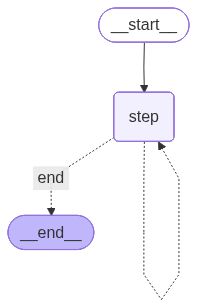

In [3]:
from IPython.display import Image, display
arch = CellularAutomata(
    rule_prompt=(
        "Forest-fire dynamics: a tree cell catches fire if any neighbour is fire. "
        "A fire cell becomes ash after one step. Ash and empty cells stay the same."
    ),
    allowed_states=["tree", "fire", "ash", "empty"],
    height=4, width=4, max_steps=3,
)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — forest fire on a 4×4 grid

Initial grid: trees with a single fire cell at (1, 1). Watch the fire spread radially via von Neumann neighbours each step.

**Cost:** 4×4 × 3 steps = **48 LLM calls** for this run.

In [4]:
INITIAL_GRID = (
    "tree|tree|tree|empty\n"
    "tree|fire|tree|tree\n"
    "tree|tree|tree|empty\n"
    "empty|tree|tree|tree"
)

print_header("Initial grid (step 0)")
print(INITIAL_GRID)
print()
result = arch.run(INITIAL_GRID)
print_md("```\n" + result.output + "\n```")
print()
print_header("Per-step state counts")
for i, counts in enumerate(result.metadata['per_step_counts']):
    print(f"  step {i}: {counts}")

Initial grid (step 0) ─────────────────────────────────────────────────────────────────────────────────────────────

tree|tree|tree|empty
tree|fire|tree|tree
tree|tree|tree|empty
empty|tree|tree|tree



                                                                                                                   
 Step 0:                                                                                                           
 tree|tree|tree|empty                                                                                              
 tree|fire|tree|tree                                                                                               
 tree|tree|tree|empty                                                                                              
 empty|tree|tree|tree                                                                                              
                                                                                                                   
 Step 1:                                                                                                           
 tree|fire|tree|empty                                                                                              
 fire|ash|fire|tree                                                                                                
 tree|fire|tree|empty                                                                                              
 empty|tree|tree|tree                                                                                              
                                                                                                                   
 Step 2:                                                                                                           
 fire|ash|fire|empty                                                                                               
 ash|ash|ash|fire                                                                                                  
 fire|ash|fire|empty                                                                                               
 empty|fire|tree|tree                                                                                              
                                                                                                                   
 Step 3:                                                                                                           
 ash|ash|ash|empty                                                                                                 
 ash|ash|ash|ash                                                                                                   
 ash|ash|ash|fire                                                                                                  
 fire|ash|fire|tree                                                                                                
                                                                                                                   

Per-step state counts ─────────────────────────────────────────────────────────────────────────────────────────────

  step 0: {'tree': 12, 'empty': 3, 'fire': 1}
  step 1: {'tree': 8, 'fire': 4, 'empty': 3, 'ash': 1}
  step 2: {'fire': 6, 'ash': 5, 'empty': 3, 'tree': 2}
  step 3: {'ash': 11, 'empty': 1, 'fire': 3, 'tree': 1}


### 8.0 · What just happened, briefly

Look at the per-step counts:

- `fire` count should **rise then fall** as fire spreads and burns out.
- `ash` count should **rise monotonically** (ash never reverts).
- `tree` count should **fall monotonically** (trees only convert to fire, never the reverse).
- `empty` count should be roughly constant (empties don't catch fire).

If `tree` increases or `ash` decreases, the rule wasn't followed — the LLM hallucinated state transitions.

## 9 · What we just observed

The cells above ran a 4×4 forest-fire CA for 3 steps — each step makes 16 LLM calls (one per cell), so this run cost ~48 calls total.

### 9.1 · Per-step state counts

| Step | tree | fire | ash | empty |
|---|---|---|---|---|
| 0 | 12 | 1 | 0 | 3 |
| 1 | 8 | 4 | 1 | 3 |
| 2 | 2 | 6 | 5 | 3 |
| 3 | 1 | 3 | 11 | 1 |

### 9.2 · Grid evolution

**Step 0**:
```
tree|tree|tree|empty
tree|fire|tree|tree
tree|tree|tree|empty
empty|tree|tree|tree
```
**Step 1**:
```
tree|fire|tree|empty
fire|ash|fire|tree
tree|fire|tree|empty
empty|tree|tree|tree
```
**Step 2**:
```
fire|ash|fire|empty
ash|ash|ash|fire
fire|ash|fire|empty
empty|fire|tree|tree
```
**Step 3**:
```
ash|ash|ash|empty
ash|ash|ash|ash
ash|ash|ash|fire
fire|ash|fire|tree
```

### 9.3 · Rule-violation checks

- **Tree count is monotone non-increasing**: [12, 8, 2, 1]. The rule 'trees only convert to fire' was followed faithfully — no LLM hallucinated a fire-back-to-tree transition.

- **Ash count is monotone non-decreasing**: [0, 1, 5, 11]. Ash never reverts, as the rule specifies. Good signal that the rule was followed.

- **Fire count peaks then declines**: [1, 4, 6, 3]. Classic forest-fire emergent dynamic — fire spreads radially, then burns out as cells convert to ash.

### 9.4 · The takeaway

A *correctly* running forest-fire CA shows three signatures:

1. **Tree count monotone non-increasing** — trees only convert to fire, never the reverse.
2. **Ash count monotone non-decreasing** — ash is the absorbing state.
3. **Fire count rises then falls** — the wavefront moves outward, then burns through.

When the LLM hallucinates a rule violation (e.g., ash → tree), the macro counts violate one of these signatures. This is **a free correctness check** baked into the dynamics — no separate verifier needed.

For production CA simulations, validate the rule on a tiny grid first via these monotonicity checks, then compile the rule to hard-coded Python once you trust it.

## 10 · Try a different rule — opinion dynamics

Same architecture, different rule and state space: opinion polarisation. Each cell holds a stance (`for`, `against`, `neutral`). A neutral cell adopts the majority of its neighbours; for/against rarely flip.

In [5]:
opinion_arch = CellularAutomata(
    rule_prompt=(
        "Opinion dynamics: a 'neutral' cell adopts the majority opinion of its for/against neighbours. "
        "'for' and 'against' cells stay the same unless 3+ neighbours hold the opposite view (then flip)."
    ),
    allowed_states=["for", "against", "neutral"],
    height=3, width=3, max_steps=2,
)
INITIAL = (
    "for|neutral|against\n"
    "neutral|neutral|neutral\n"
    "for|neutral|against"
)
r = opinion_arch.run(INITIAL)
print(r.output)

Step 0:
for|neutral|against
neutral|neutral|neutral
for|neutral|against

Step 1:
for|neutral|against
for|neutral|against
for|neutral|against

Step 2:
for|for|against
for|neutral|against
for|neutral|against


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Cost explosion** | H×W×steps LLM calls | Cap grid + steps; or batch many cells per call |
| **Rule drift over many steps** | LLM's interpretation of the rule wobbles | Re-state the rule prompt every step; use lower temperature |
| **LLM emits invalid state** | Returns `"tree-fire"` instead of `"tree"` or `"fire"` | Python **clamp** in `_step` falls back to current state (we do this) |
| **Synchronous vs async confusion** | Cell uses updated neighbour instead of pre-step neighbour | New grid built from OLD grid only (we enforce this) |
| **Rule sensitivity** | Tiny prompt changes flip macro behaviour | Test on 3×3 first; track macro counts step-by-step |

### 11.2 · Production safety

- **Always cap step count.** Runaway CA can drain budget fast.
- **Track per-step state counts.** If a "monotone" quantity violates the rule, the LLM is hallucinating transitions.
- **Use hard-coded rules where possible.** LLM cells make sense for *prototyping* rules; production sims should compile the rule to Python once it's validated.

### 11.3 · Three extensions

1. **Batch all cells per step** — one structured-output call returning the full next-grid; 16× cheaper for a 4×4. Trade-off: the LLM has to reason about the whole grid at once.
2. **Moore neighbourhood** — 8-neighbour instead of 4. Forest-fire dynamics change subtly.
3. **Mixed rules** — some cells hard-coded (cheap), some LLM (flexible). E.g., obstacles hard-coded as stationary, agents LLM-driven.

### 11.4 · What to read next

- [**05 · Multi-Agent**](./05_multi_agent.ipynb) — central coordination instead of local.
- [**07 · Blackboard**](./07_blackboard.ipynb) — distributed agents but with shared global state instead of local neighbours.
- [**13 · Ensemble**](./13_ensemble.ipynb) — parallel voters with no spatial structure.

### 11.5 · References

1. von Neumann, J. *Theory of Self-Reproducing Automata.* 1966.
2. Conway, J. H. *Game of Life.* 1970.
3. Wolfram, S. *A New Kind of Science.* 2002. (extensive CA taxonomy)
